In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib as mpl
plt.style.use("ggplot")
plt.rcParams["figure.dpi"] = 100
font = {"family": "sans-serif", "size": 12}

mpl.rc("font", **font)

from IPython.display import Image

In [3]:
df = pd.read_csv("credit_risk_dataset.csv")

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [7]:
print(df.dtypes)

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object


## EDA

In [5]:
df.shape

(32581, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


| Column | Description |
|---|---|
| `person_age` | Age of the loan applicant in years. |
| `person_income` | Annual income of the loan applicant. |
| `person_home_ownership` | Applicant's home ownership status, such as rent, own, or mortgage. |
| `person_emp_length` | Length of employment of the applicant in years. |
| `loan_intent` | Purpose for which the loan is requested, such as education, medical, personal, or home improvement. |
| `loan_grade` | Credit risk grade assigned to the loan, indicating the borrower's creditworthiness. |
| `loan_amnt` | Amount of money requested/issued as the loan. |
| `loan_int_rate` | Interest rate associated with the loan. |
| `loan_status` | **Target variable** indicating whether the loan defaulted (`1`) or did not default (`0`). |
| `loan_percent_income` | Loan amount expressed as a proportion of the applicant's annual income. |
| `cb_person_default_on_file` | Indicates whether the applicant has a previous default recorded in their credit history. |
| `cb_person_cred_hist_length` | Length of the applicant's credit history in years. |

In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

[1 0]
loan_status
0    25473
1     7108
Name: count, dtype: int64


<Axes: xlabel='loan_status', ylabel='percent'>

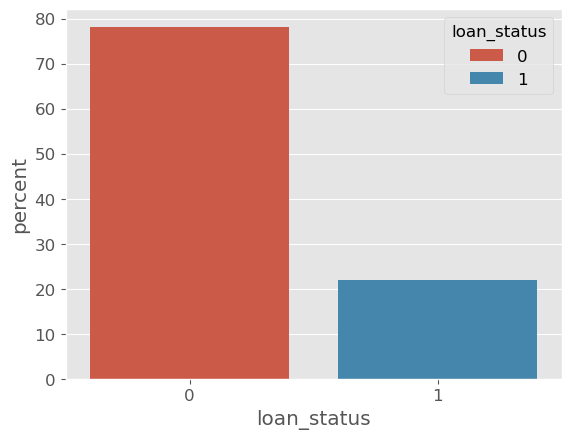

In [8]:
# loan status if the target;
print(df.loan_status.unique())
print(df['loan_status'].value_counts())

sns.countplot(df, x = 'loan_status', stat='percent', hue='loan_status')
# there are class imbalance between the 0 and 1 class


In [9]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Numeric Columns:  ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'] and its length is  7
Categorical Columns:  ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'] and its length is  4
####################
Negative values
person_age                    0
person_income                 0
person_emp_length             0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_cred_hist_length    0
dtype: int64


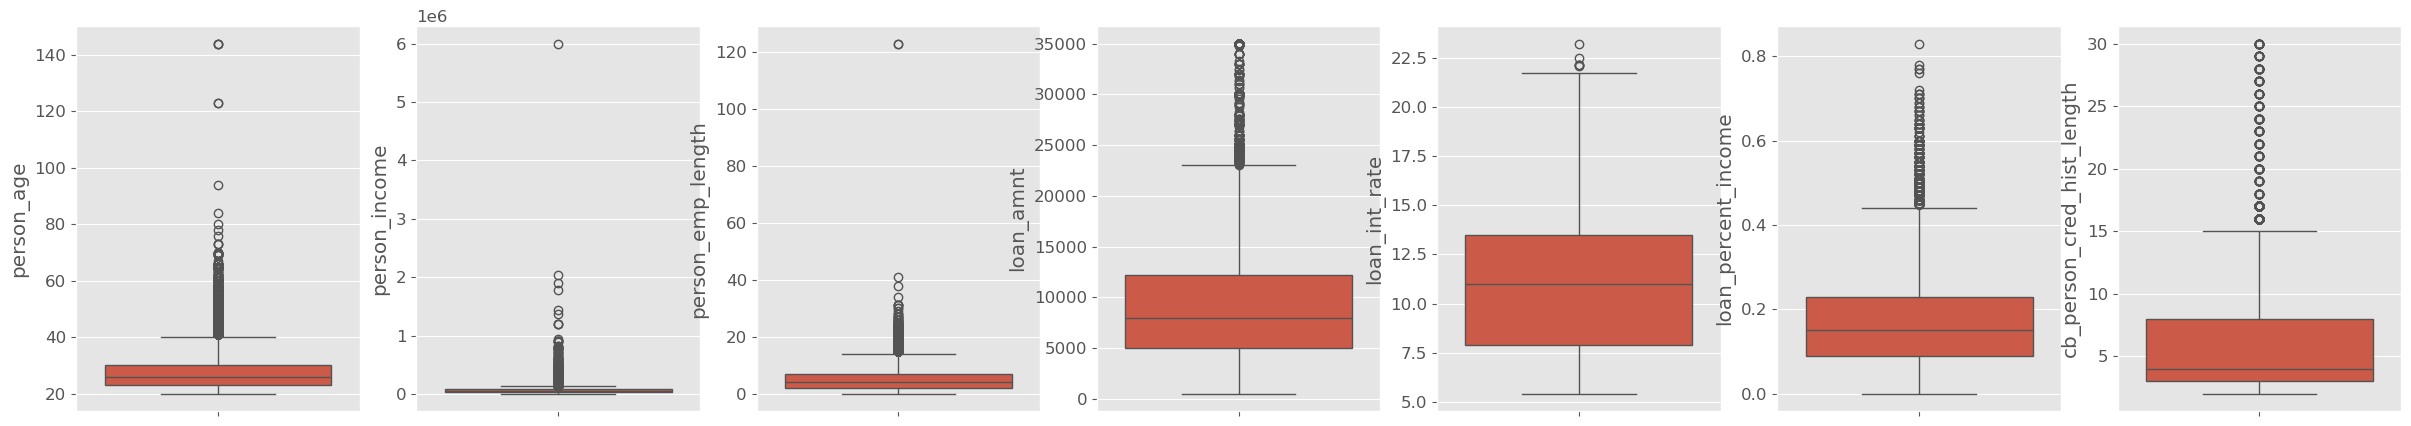

In [10]:
# Check outliers

numeric_cols = df.drop('loan_status',axis=1).select_dtypes(exclude=['object']).columns.tolist()

categorical_cols = df.drop('loan_status',axis=1).select_dtypes(include=['object']).columns.tolist()

##
print('Numeric Columns: ', numeric_cols, 'and its length is ', len(numeric_cols))
print('Categorical Columns: ', categorical_cols, 'and its length is ', len(categorical_cols))




print('#'*20)
negative_counts = (df[numeric_cols] < 0).sum()
print('Negative values')
print(negative_counts)

###Boxplot
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(30,5))
for col, ax  in zip(numeric_cols, axes):
    if df[col].dtype != 'object':
        sns.boxplot(y = df[col], ax= ax)

In [11]:
# Check if age > 100 and < 18 ; they should not get loan
print((df['person_age'] >100).sum(), (df['person_age'] < 18).sum()) 


5 0


In [12]:
## Unphysicals?? 
# is there rows with -ve income
print((df['person_income'] < 0).sum())

# if the loan percent income > 1 
print((df['loan_percent_income'] > 1).sum())

0
0


In [13]:
# is employment length > age ? This is unphysical
df['person_emp_length'] > df['person_age']


0         True
1        False
2        False
3        False
4        False
         ...  
32576    False
32577    False
32578    False
32579    False
32580    False
Length: 32581, dtype: bool

Mean: 66075, Median: 55000


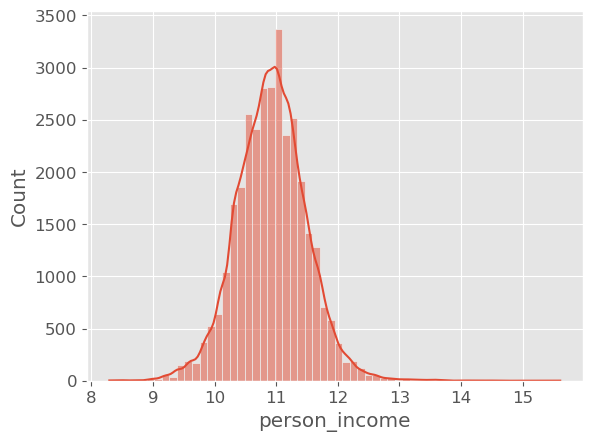

In [14]:
sns.histplot(np.log(df["person_income"]), bins=60, kde=True)
# data is right skewed: mean > median
print(f"Mean: {df["person_income"].mean():.0f}, Median: {df["person_income"].median():.0f}")


<Axes: >

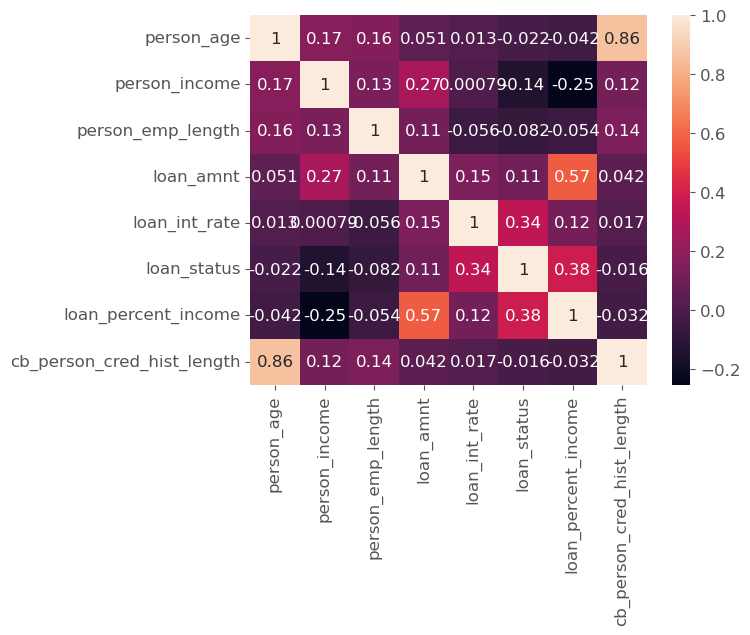

In [15]:
# Pearson correlation
sns.heatmap(df.corr(numeric_only=True), annot=True)


#  
# 

In [16]:
df.duplicated().sum()

np.int64(165)

Inferences: 
- 4 object columns
- nan values  
- duplicate rows
- person's age and cibil credited person's length are highly correlated
- age > 100 exists
- class imbalance in loan status
- person's emp length > person's age exists
- Outliers are there  

## Preprocessing
-  Remove duplicate rows
- 18 < age < 100
- age > person emp length
- 

In [17]:
# Remove duplicates
df_copy = df.copy() # copy the org df
df_copy.drop_duplicates(inplace=True)
print(f"Print rows before and after droppping duplicates: {df.shape[0]} & {df_copy.shape[0]}")


Print rows before and after droppping duplicates: 32581 & 32416


In [18]:
# 18 < Age < 100
df_copy = df_copy[(df_copy['person_age'].between(18,100))]
print(f" after age selection in between [18,100]: {df_copy.shape[0]}")

# Emplyment length < age
df_copy  = df_copy[ (df_copy['person_age'] > df_copy['person_emp_length'])  ]
print(f" after Emplyment length < age: {df_copy.shape[0]}")
df_copy.describe()

#The interest rest looks realistic

 after age selection in between [18,100]: 32411
 after Emplyment length < age: 31522


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31522.000000,3.152200e+04,31522.000000,31522.000000,28495.000000,31522.000000,31522.000000,31522.000000
mean,27.742529,6.650168e+04,4.782850,9663.771334,11.045220,0.215944,0.169658,5.816097
std,6.218713,5.275216e+04,4.037343,6334.787700,3.230786,0.411482,0.106296,4.063622
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.943800e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [19]:
#We are not removing outliers though they are present but it seems realistic:
#If we have to then will do it after train-test split to avoide any data leakage

## Train - Test Split

In [20]:
X = df_copy.drop('loan_status', axis = 1)
y = df_copy['loan_status']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handling Class imbalance

- SMOTE can alter the data, lets avoide that here 
- use `class_weight` which is built in `Logistic Regression` --> **balanced** option automatically gives more weight to the minority class.
Conceptually:
$$
w_c = \frac{N}{K N_c}
$$
where $N_c$ is the number of observations in class $c$.


- Models like XGboost has `scale_pos_weight`.
$$ scale_pos_weight = \frac{N_{\textrm{negative}}}{N_{\textrm{positive}}} $$



In [22]:
y_train.value_counts()

loan_status
0    19772
1     5445
Name: count, dtype: int64

In [23]:
y_test.value_counts()

loan_status
0    4943
1    1362
Name: count, dtype: int64

In [24]:
scale_pos_weight = y_train.value_counts()[0]/ y_train.value_counts()[1]
print(scale_pos_weight)

3.6312213039485766


## Preprocessing for Logistic Regression

Though tree based classifier donot get affected by the scale of the data linear models might ; 
- do standrad scalar tranformation (x-mu /sigma) on the numerical columns 
- One-hot encoding on the categorical columns  
  The best way to handle this is uisng `ColumnTransformer` to avoide data leakage

In [25]:
# impute + Scale  Nuremic; impute + one-hot-encoading on Categorical columns 
# numerical pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Pipeline for numerical columns 
numeric_pipeline_lr = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="median")), # fill missing values with median
        ("scaler", StandardScaler()) # perform standard scalar
    ]
)

# Pipeline for categorical columns 
categorical_pipeline_lr = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")), # Fill the null values with "Missing"  
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

#Combine both using ColumnTransformer

preprocessor_lr = ColumnTransformer([
    ("num", numeric_pipeline_lr, numeric_cols),
    ("cat", categorical_pipeline_lr, categorical_cols),
])

In [26]:
# Load the model 
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("model", LogisticRegression(
              class_weight="balanced",
              max_iter=1000,
              random_state=42          
    ))
])

logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Preprocessing for XGBoost

In [27]:
# No need of scaling , Impute + one-hot-encoding

# Pipeline for numerical columns 
numeric_pipeline_XG = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Pipeline for categorical columns 
categorical_pipeline_XG = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")), # Fill the null values with "Missing"  
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

#Combine both using ColumnTransformer
preprocessor_XG = ColumnTransformer([
    ("num", numeric_pipeline_XG, numeric_cols),
    ("cat", categorical_pipeline_XG, categorical_cols),
])

In [28]:
import xgboost
from xgboost import XGBClassifier
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor_XG),
    ("model", XGBClassifier(
              scale_pos_weight = scale_pos_weight, # using the class weight
              n_estimators=300, 
              max_depth=5, 
              learning_rate=0.1,
              random_state=42
    ))
])
xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

# Ensemble Classifier using bootstrap aggregating (bagging) : Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_XG),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

## A Gradient boosting model: LightGBM

In [30]:
import lightgbm
from lightgbm import LGBMClassifier

lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor_XG),
    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=-1,
        random_state=42,
        verbosity = -1,
        class_weight="balanced"
    ))
])

/home/amandip/miniconda3/envs/AD_GPU1/lib/python3.12/site-packages/distributed/diagnostics/rmm.py:8: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
  import rmm
/home/amandip/miniconda3/envs/AD_GPU1/lib/python3.12/site-packages/rmm/__init__.py:17: FutureWarning: The cuda.cuda module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.driver module instead.
  from rmm import mr


## Another Gradient boosting model using ordered target encoding: CatBoost 

In [31]:
from catboost import CatBoostClassifier
# we are not using CatBoost's native categorical feature processing

catboost_pipeline = Pipeline([
    ("preprocessor", preprocessor_XG),
    ("model", CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=0
    ))
])

## Stratified Cross Validation for models

For CV  we need : i) model 2) train data X_train, y_train => we will store the scores 


In [32]:
#Because loan_status is imbalanced, use StratifiedKFold, not ordinary KFold
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc':'roc_auc',"pr_auc": "average_precision", 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [33]:
import warnings


warnings.filterwarnings(
    "ignore",message="X does not have valid feature names") # to ignore warnings for df to numpy conversion


In [34]:
results = {}

for model_name, pipe in [ ("Logistic Regression", logistic_pipeline),
                          ("XGBoost", xgb_pipeline),
                          ("RandomForest", rf_pipeline),
                          ("LightGBM", lgbm_pipeline),
                          ("CatBoost", catboost_pipeline)
                            
                        ]:
                        #print(model_name, pipe)
                        cv_results= cross_validate(pipe,X_train,y_train, cv=cv,scoring=scoring,n_jobs=-1)
                        
                        results[model_name] = cv_results
    
                        print(f"\n{model_name}")
                        print("-" * 40)
    
                        for metric in scoring:
                            scores = cv_results[f"test_{metric}"]
        
                            print(
                                f"{metric:10s}: "
                                f"{scores.mean():.4f} ± {scores.std():.4f}")
                        


Logistic Regression
----------------------------------------
roc_auc   : 0.8705 ± 0.0049
pr_auc    : 0.7135 ± 0.0065
accuracy  : 0.8116 ± 0.0046
precision : 0.5448 ± 0.0087
recall    : 0.7781 ± 0.0087
f1        : 0.6408 ± 0.0036

XGBoost
----------------------------------------
roc_auc   : 0.9472 ± 0.0045
pr_auc    : 0.9026 ± 0.0057
accuracy  : 0.9182 ± 0.0027
precision : 0.8195 ± 0.0151
recall    : 0.7974 ± 0.0110
f1        : 0.8081 ± 0.0046

RandomForest
----------------------------------------
roc_auc   : 0.8990 ± 0.0055
pr_auc    : 0.8248 ± 0.0068
accuracy  : 0.8767 ± 0.0044
precision : 0.6976 ± 0.0136
recall    : 0.7579 ± 0.0077
f1        : 0.7264 ± 0.0069


/home/amandip/miniconda3/envs/AD_GPU1/lib/python3.12/site-packages/distributed/diagnostics/rmm.py:8: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
  import rmm
/home/amandip/miniconda3/envs/AD_GPU1/lib/python3.12/site-packages/rmm/__init__.py:17: FutureWarning: The cuda.cuda module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.driver module instead.
  from rmm import mr
/home/amandip/miniconda3/envs/AD_GPU1/lib/python3.12/site-packages/distributed/diagnostics/rmm.py:8: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
  import rmm
/home/amandip/miniconda3/envs/AD_GPU1/lib/python3.12/site-packages/rmm/__init__.py:17: FutureWarning: The cuda.cuda module is deprecated and will be removed in a future release, please switch to use 


LightGBM
----------------------------------------
roc_auc   : 0.9458 ± 0.0044
pr_auc    : 0.9021 ± 0.0064
accuracy  : 0.9251 ± 0.0015
precision : 0.8575 ± 0.0102
recall    : 0.7838 ± 0.0137
f1        : 0.8188 ± 0.0047

CatBoost
----------------------------------------
roc_auc   : 0.9440 ± 0.0048
pr_auc    : 0.8984 ± 0.0067
accuracy  : 0.9187 ± 0.0018
precision : 0.8273 ± 0.0130
recall    : 0.7888 ± 0.0131
f1        : 0.8074 ± 0.0038


In [35]:
results

{'Logistic Regression': {'fit_time': array([0.08299661, 0.07259488, 0.08126998, 0.08633542, 0.07329202]),
  'score_time': array([0.02355218, 0.02255392, 0.02573442, 0.02602386, 0.02381253]),
  'test_roc_auc': array([0.87315402, 0.86441823, 0.86989451, 0.87835406, 0.8667356 ]),
  'test_pr_auc': array([0.71193162, 0.71287357, 0.71064093, 0.72566624, 0.70623267]),
  'test_accuracy': array([0.81403648, 0.81919112, 0.8104303 , 0.806861  , 0.80745588]),
  'test_precision': array([0.54867827, 0.55967633, 0.54254639, 0.53587024, 0.53734177]),
  'test_recall': array([0.78145087, 0.76216713, 0.77869605, 0.78879706, 0.77961433]),
  'test_f1': array([0.64469697, 0.64541213, 0.63951735, 0.63818722, 0.63619333])},
 'XGBoost': {'fit_time': array([0.32937574, 0.33430767, 0.34814   , 0.33073211, 0.32573009]),
  'score_time': array([0.04777598, 0.060637  , 0.07045436, 0.04835439, 0.04811978]),
  'test_roc_auc': array([0.94953303, 0.93862031, 0.94699977, 0.95139258, 0.94928849]),
  'test_pr_auc': array([

## Creating a Helper function:

To check each models performance:
- accuracy, precision, F1 score, etc.
- confusion matrix and ROC  

In [36]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, recall_score,  precision_score, precision_recall_curve, confusion_matrix, average_precision_score


def evalution_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:,1]
    
    # Accuracy score
    accuracy_scr = accuracy_score(y_test, y_pred) #(TP+TN)/TP+TN+FP+FN
    #Precision score
    precision_scr = precision_score(y_test, y_pred) #TP/TP+FP
    #Recall score
    recall_scr = recall_score(y_test, y_pred) #TP/TP+FN
    #F1 score
    f1_scr = f1_score(y_test, y_pred) # 2.(precision*recall)/(precision+recall)
    
    #confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    classfication_rpt = classification_report(y_test, y_pred)
    
    print("#"*80)
    print(f"Model: {model_name}")
    print("#"*80)
    
    print(f"Accuracy: {accuracy_scr:.2f}")
    print(f"Precision: {precision_scr:.2f}")
    print(f"Recall: {recall_scr:.2f}")
    print(f"F1: {f1_scr:.2f}")
    
    # Plotting the confusion matrix
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel(f"Predicted Values")
    plt.ylabel(f"Actual Values")
    plt.show()
        
    #Plotting ROC-AUC
    precision, recall, thresholds  = precision_recall_curve(y_test, y_pred_prob)
    pr_auc_val = average_precision_score(y_test, y_pred_prob)
    
    plt.plot(recall, precision, color='crimson', lw=2.5, label=f'{model_name} (PR-AUC = {pr_auc_val:.4f})')
    plt.title(f"{model_name}: Precision-Recall Curve")
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.legend(loc='lower center')
    plt.grid(alpha=0.3)


## Creating a baseline model : Goal is to beat this model

In [37]:
#
baseline_model = logistic_pipeline
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

################################################################################
Model: Logistic Regression
################################################################################
Accuracy: 0.82
Precision: 0.56
Recall: 0.79
F1: 0.65


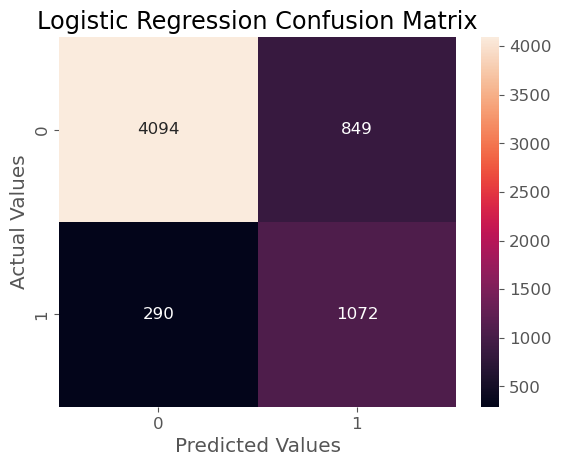

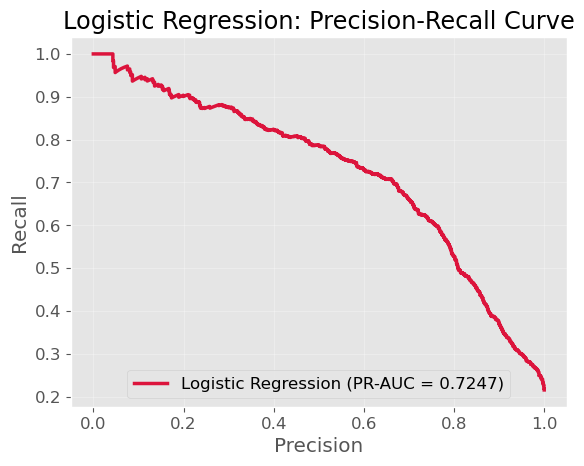

In [38]:
evalution_model("Logistic Regression", baseline_model, X_test, y_test)

In [39]:
xgb_model = xgb_pipeline
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

################################################################################
Model: XGBoost
################################################################################
Accuracy: 0.92
Precision: 0.82
Recall: 0.81
F1: 0.81


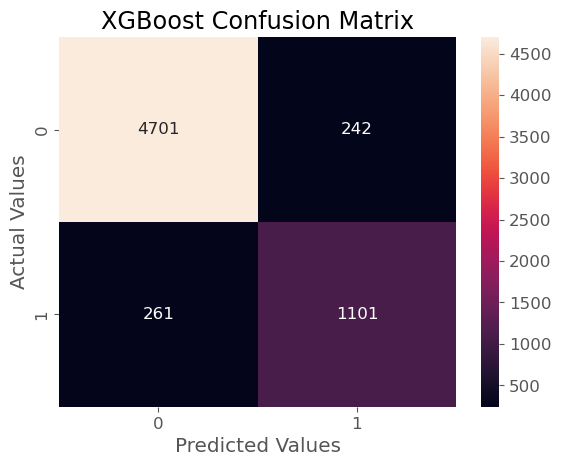

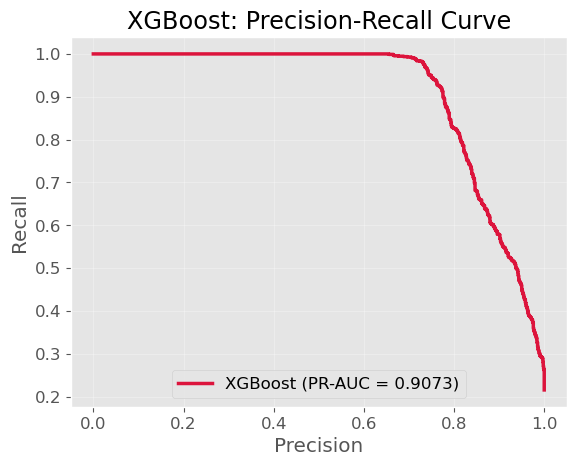

In [40]:
evalution_model("XGBoost", xgb_model, X_test, y_test)


## Hyperparameter tuning using Grid search

A systematic grid search with stratified 5-fold cross-validation was performed over the selected XGBoost hyperparameter

In [41]:
# lets choose XGBoost since it has the best AUC score; and tune the hyperparameters 

from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [200, 300, 500], # Number of boosting trees
    "model__max_depth": [3, 5, 7],  # Maximum depth of each tree
    "model__learning_rate": [0.05, 0.1],  # Step size for each boosting iteration
    "model__min_child_weight": [1, 3], # Minimum sum of instance weights in a child
    "model__colsample_bytree": [0.8, 1.0], # Fraction of features used per tree
    "model__subsample": [0.8, 0.9, 1.0], # Fraction of samples used per tree
    #"model__gamma": [0,1,2,3,4,5]   # Minimum loss reduction required for a split; lower gamma -> complex tree
}
# Current grid combinations : 3*3*2*2*2*3*6 = 1296

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5, ...], 'model__min_child_weight': [1, 3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, t

In [42]:
print("Best PR-AUC:", grid_search.best_score_)
print("Best parameters:")
print(grid_search.best_params_)

Best PR-AUC: 0.9044466790195553
Best parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 500, 'model__subsample': 1.0}


In [43]:
best_xgb = grid_search.best_estimator_

################################################################################
Model: XGBoost Hyperpara
################################################################################
Accuracy: 0.92
Precision: 0.83
Recall: 0.80
F1: 0.81


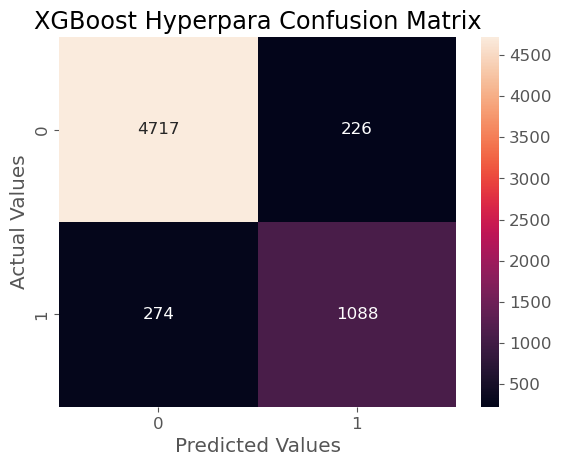

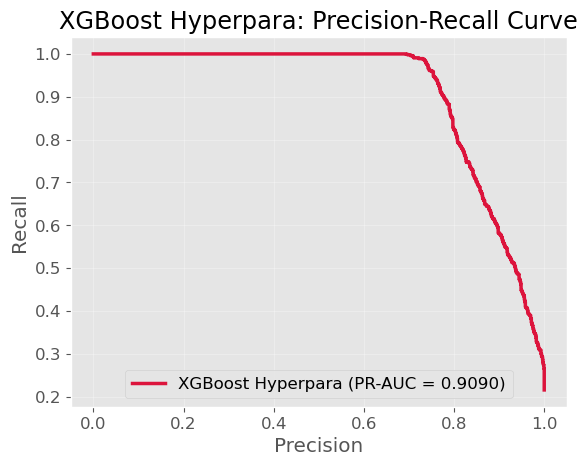

In [47]:
evalution_model("XGBoost Hyperpara", best_xgb, X_test, y_test)

## Optimizing classifier threshold


In [72]:
from sklearn.metrics import precision_recall_curve
# Get the prob of loan_status =1
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# precision and recall for each threshold
precision, recall, thresholds = precision_recall_curve(y_test,y_prob)
# len of precision and recall should be same but len(threshold) = len(recall) -1 ; 
# because of the last point not having a threshold 

assert len(precision) == len(recall)
assert len(precision) == len(thresholds) + 1

#Calculate F1 score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

#Get the threshold that produces the highest f1-score ;; remember the len 
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best index     :", best_idx)
print("Best threshold :", best_threshold)
print("Best F1        :", best_f1)
print("Precision      :", precision[best_idx])
print("Recall         :", recall[best_idx])

Best index     : 5234
Best threshold : 0.6992284
Best F1        : 0.844225235840897
Precision      : 0.9589169000933707
Recall         : 0.7540381791483113


So at this threshold which differs from usual 0.5 ==> 
- among customers predicted as loan_status = 1, about 95.9% are actually defaults, while we identify about 75.4% of the actual defaults.

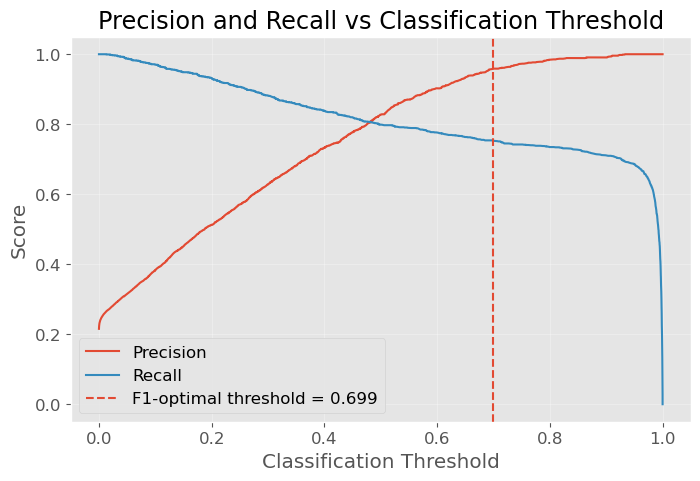

In [73]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"F1-optimal threshold = {best_threshold:.3f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Probability Calibration 

Probability calibration is the process of adjusting a machine learning model's output scores so they match the true statistical likelihood of an event. Its a technique used to convert the output scores from a binary classifier into probabilities to correlate with the actual probabilities of the target class.

If a model predicts an 80% chance of an event, a well-calibrated model is correct 80% of the time on average.

What is teh need??
- **Honest Confidence:** Many models (like Support Vector Machines or Naive Bayes) output raw scores or overconfident probabilities that do not reflect actual accuracy.


- **Better Decision-Making:** High-stakes fields like banking (loan approvals) and healthcare (disease risk) require trustworthy risk thresholds rather than simple class rankings.

- **Preserved Ranking:** Calibration fixes the probability scale without ruining the model's underlying ability to sort positive cases from negative ones. Users on Reddit generally reach a consensus that calibration leaves metrics like ROC-AUC unchanged because it modifies absolute probabilities rather than the ranking order.


`Common Methods`

- **Platt Scaling:** Fits a logistic regression model to the classifier's raw scores. It works best for smaller datasets and models with sigmoid-shaped biases.

- **Isotonic Regression:** Fits a non-parametric, piecewise-constant monotonic function. It is highly flexible for large datasets (over 1,000 samples) but can overfit smaller data.

`How to Measure Calibration`

- Reliability Diagram (Calibration Curve): A plot of predicted probability bins against the true empirical frequency. A perfect model follows the 45-degree diagonal line.

- Brier Score: The mean squared error between predicted probabilities and actual binary outcomes.
- Expected Calibration Error (ECE): The weighted average gap between predicted confidence bins and reality


A good check for model calibrationis done here: 

https://www.kaggle.com/code/abhishekmungoli/model-calibration

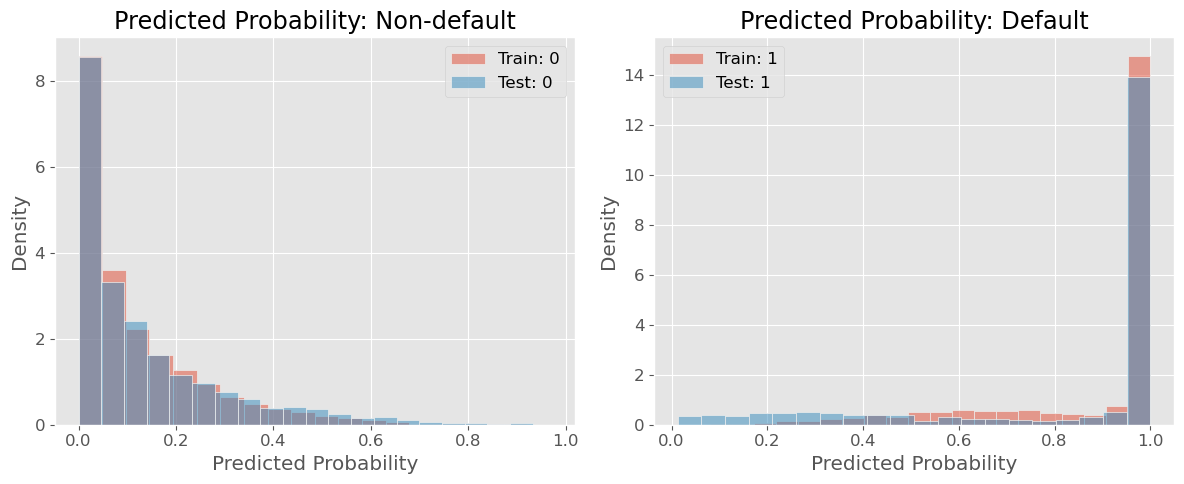

Train:
count    2.521700e+04
mean     2.841207e-01
std      3.487534e-01
min      4.455229e-07
25%      2.879255e-02
50%      1.149681e-01
75%      4.043147e-01
max      9.999996e-01
dtype: float64

Test:
count    6305.000000
mean        0.282879
std         0.345004
min         0.000001
25%         0.028194
50%         0.121855
75%         0.392362
max         1.000000
dtype: float64


In [80]:
# First Lets compare how the train and test predicted probablility looks like

y_prob_test = best_xgb.predict_proba(X_test)[:, 1]
y_prob_train = best_xgb.predict_proba(X_train)[:, 1]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

sns.histplot(y_prob_train[y_train.values == 0],bins=20,stat="density",alpha=0.5,label="Train: 0")
sns.histplot(y_prob_test[y_test.values == 0],bins=20,stat="density",alpha=0.5,label="Test: 0")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.title("Predicted Probability: Non-default")
plt.legend()


plt.subplot(1, 2, 2)

sns.histplot(y_prob_train[y_train.values == 1],bins=20,stat="density",alpha=0.5,label="Train: 1")
sns.histplot(y_prob_test[y_test.values == 1],bins=20,stat="density",alpha=0.5,label="Test: 1")

plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.title("Predicted Probability: Default")
plt.legend()

plt.tight_layout()
plt.show()
## Neumerically 
print("Train:")
print(pd.Series(y_prob_train).describe())

print("\nTest:")
print(pd.Series(y_prob_test).describe())


The test and train are behaving almost similar. But is it calibrated?

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

## Platt scalling best works for the not a large dataset 

calibrated_xgb = CalibratedClassifierCV(
    best_xgb, 
    method = "sigmoid",
    cv = 5,
    n_jobs=-1)

calibrated_xgb.fit(X_train, y_train)


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",-1
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the colum

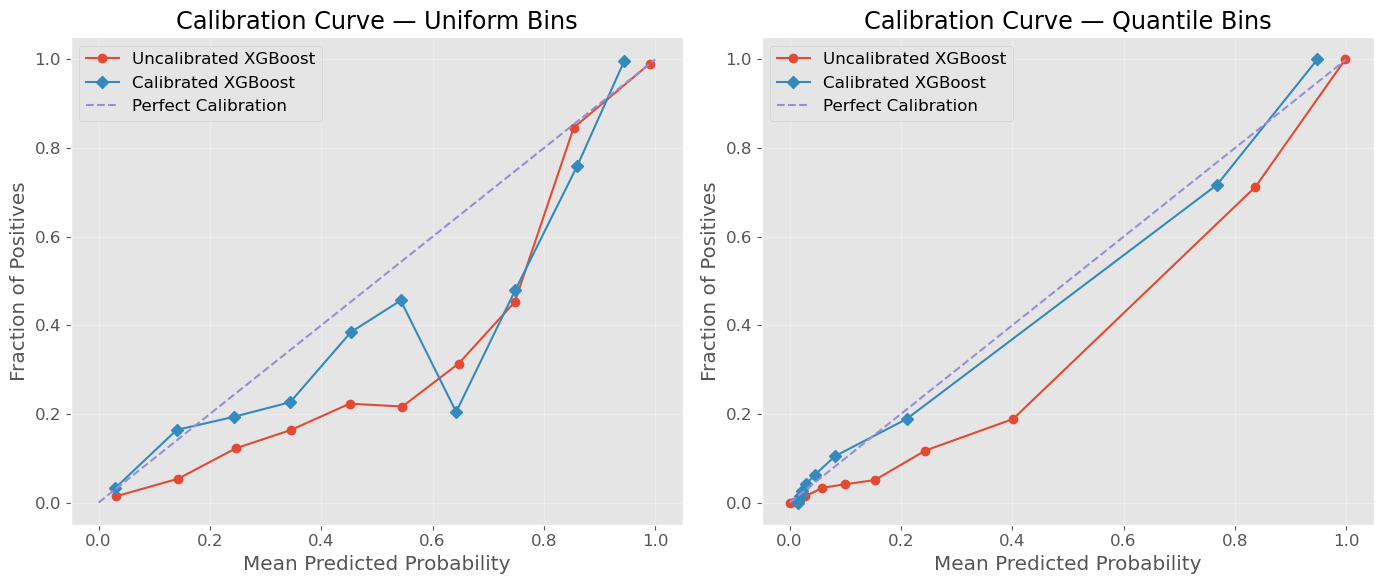

Brier score uncalibrated: 0.061337731778621674
Brier score calibrated: 0.05230700762155586


In [ ]:
from sklearn.calibration import calibration_curve

from sklearn.metrics import brier_score_loss

# Get probabilities for calibrated and uncalibrated models
y_prob_uncalibrated = best_xgb.predict_proba(X_test)[:, 1]
y_prob_calibrated = calibrated_xgb.predict_proba(X_test)[:, 1]


# --------------------------------------------------
# 1. Uniform strategy
# --------------------------------------------------

actual_uncal_uniform, predicted_uncal_uniform = calibration_curve(y_test,y_prob_uncalibrated,n_bins=10,
    strategy="uniform"
)

actual_cal_uniform, predicted_cal_uniform = calibration_curve(y_test,y_prob_calibrated,n_bins=10,
    strategy="uniform"
)


# --------------------------------------------------
# 2. Quantile strategy
# --------------------------------------------------

actual_uncal_quantile, predicted_uncal_quantile = calibration_curve(y_test,y_prob_uncalibrated,n_bins=10,
    strategy="quantile"
)

actual_cal_quantile, predicted_cal_quantile = calibration_curve(y_test,y_prob_calibrated,n_bins=10,
                                                                strategy="quantile")


# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(14, 6))

# Uniform bins
plt.subplot(1, 2, 1)

plt.plot(predicted_uncal_uniform,actual_uncal_uniform,marker="o",label="Uncalibrated XGBoost")

plt.plot(predicted_cal_uniform,actual_cal_uniform,marker="D",label="Calibrated XGBoost")

plt.plot([0, 1],[0, 1],linestyle="--",label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve — Uniform Bins")
plt.legend()
plt.grid(alpha=0.3)


# Quantile bins
plt.subplot(1, 2, 2)

plt.plot(predicted_uncal_quantile,actual_uncal_quantile,marker="o",label="Uncalibrated XGBoost")

plt.plot(predicted_cal_quantile,actual_cal_quantile,marker="D",label="Calibrated XGBoost")

plt.plot([0, 1],[0, 1],linestyle="--",label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve — Quantile Bins")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Brier score : lower the better

print("Brier score uncalibrated:", brier_score_loss(y_test, y_prob_uncalibrated))
print("Brier score calibrated:", brier_score_loss(y_test, y_prob_calibrated))

The calibrated model is performing better as the Brier score is lower for that.

In [101]:
## Check if the calibrated model changes F1 score or other matrices: should be very minimal

## SHAP Interpretation -- Global and Local

- Helps under the blackbox model: which input draw the classfication by what factor. It provides both local interpretation (explaining a single prediction) and global interpretation (explaining overall model behavior).

You can also get this feature importance in terms of `weight, gain, cover` from the **XGBoost** (global)itself but SHAP offers a more detailed estimation because of the global and local interpretation. For XGBoost

```
booster = model.get_booster()

importance_weight = booster.get_score(importance_type='weight')
importance_gain = booster.get_score(importance_type='gain')
importance_cover = booster.get_score(importance_type='cover')
```

In [115]:
# we donot need the calibrated model, rather use the best_xgb 

import shap

# Get the trained XGBoost classifier model out of the pipeline
preprocessor_XBG = best_xgb.named_steps["preprocessor"]
XBG_model = best_xgb.named_steps["model"]
print(XBG_model)

# Transform the test data with the same preprocessing
X_test_transformed = preprocessor_XBG.transform(X_test)

 
# Get the feature names after one-hot encoading , so that plots are readable
feature_names = preprocessor_XBG.get_feature_names_out() 
print("#"*40)
print("Feature Names Extraction with one hot encoading")
print("#"*40)
print("Original features:", X_test.shape[1])
print("Transformed features:", len(feature_names))
print(feature_names)

# Conver to a datafraame for a more cleaner SHAP plot
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Create SHAP explainer built for tree-based model  
explainer = shap.TreeExplainer(XBG_model)

# Create SHAP caluesw for every row in the test set
shap_values = explainer(X_test_transformed_df)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)
########################################
Feature Names Extraction with one hot encoading
########################################
Original features: 11
Transformed features: 26
['num__person_age' 'num__person_income' 'num__person_emp_length'
 'num_

In [116]:
shap_values

.values =
array([[-2.67449796e-01, -3.50900888e-01,  4.40295368e-01, ...,
        -7.82783329e-03, -3.67912985e-02, -1.08729359e-02],
       [-6.20378479e-02, -1.08416176e+00,  7.72782564e-02, ...,
        -9.85231716e-03,  4.81517194e-03,  6.94645382e-03],
       [ 1.97808832e-01,  4.79459524e+00,  9.24667120e-02, ...,
        -7.64888339e-03,  2.71048620e-02,  4.19357326e-03],
       ...,
       [-3.56320059e-03,  1.03638232e+00,  1.61718294e-01, ...,
        -9.29720886e-03, -5.28350007e-03, -2.21943788e-04],
       [-9.56437215e-02, -1.63271821e+00,  8.98749903e-02, ...,
        -1.08377216e-02, -9.13446583e-03, -8.18899833e-03],
       [-3.28109592e-01, -1.46576369e+00, -1.15555085e-01, ...,
        -1.00199683e-02,  1.05261453e-03,  3.92731559e-03]],
      shape=(6305, 26), dtype=float32)

.base_values =
array([0.00254836, 0.00254836, 0.00254836, ..., 0.00254836, 0.00254836,
       0.00254836], shape=(6305,), dtype=float32)

.data =
array([[2.4000e+01, 3.0000e+04, 1.0000e+00, ...

## Global Explanation
- Shows which features matter most
- Shows if a features inceases or decreases risk

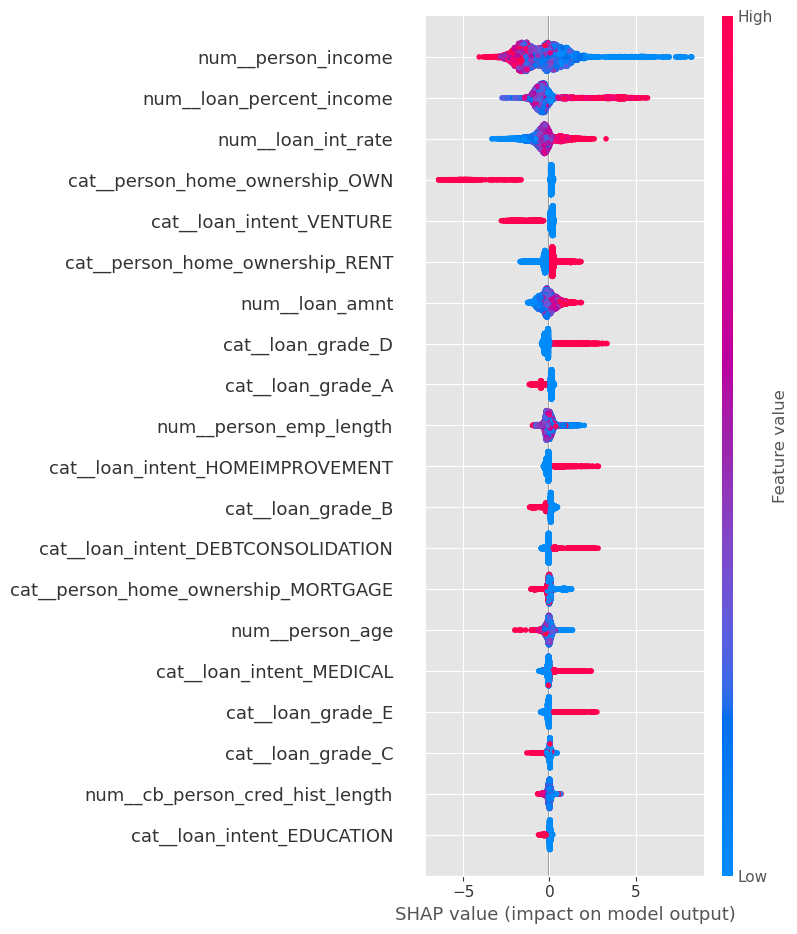

In [ ]:
shap.summary_plot(shap_values, X_test_transformed_df)

## Local explanation 
- this shows why one specific applicant got their score
- it breaks the score down feature bu feature



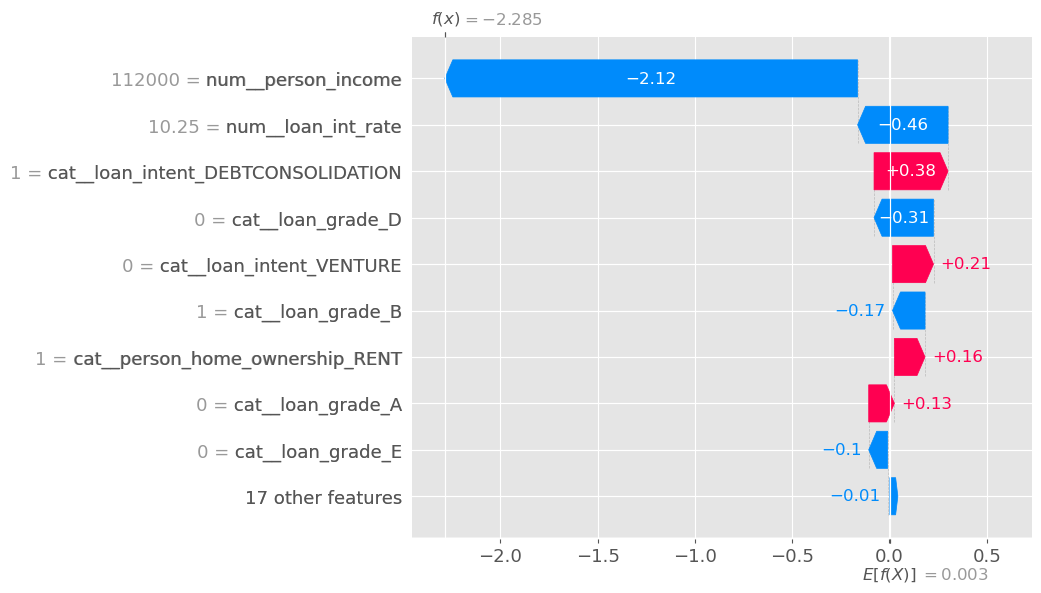

In [123]:
#pick a row in test set 
row_index = 10

# draw a waterfall plot showing how each feature pushed the prediction up or down
#display(shap_values[row_index])

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[row_index],
        base_values=explainer.expected_value,
        data = X_test_transformed_df.iloc[row_index],
        feature_names=feature_names
    )
)

## Analyzing False Positive and False Negative

- False positive are safe people wrongly marked risky 
- False negative are risky people wrongly marked as safe
- This study is to underastand where the model struggles


In [129]:
# Get the predictions from the best performing XGBoost model on the test set

y_pred = calibrated_xgb.predict(X_test)
result_df = X_test.copy()
result_df['actual'] =  y_test
result_df['predicted'] =  y_pred
result_df



,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,actual,predicted
14455,24,30000,OWN,1.0,MEDICAL,E,15000,15.68,0.50,N,3,1,0
8701,23,60000,MORTGAGE,6.0,EDUCATION,C,25600,NaN,0.43,N,4,0,0
19804,29,18000,RENT,2.0,EDUCATION,C,3600,15.27,0.20,N,6,1,1
27252,32,130000,MORTGAGE,7.0,MEDICAL,B,13000,12.69,0.10,N,8,0,0
5610,23,45288,MORTGAGE,7.0,DEBTCONSOLIDATION,B,20500,9.25,0.45,N,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11661,21,75000,MORTGAGE,5.0,PERSONAL,C,20000,13.11,0.27,Y,2,0,0
27837,29,265000,MORTGAGE,2.0,PERSONAL,B,25000,11.26,0.09,N,10,0,0
17192,25,48996,MORTGAGE,8.0,MEDICAL,B,5000,9.88,0.10,N,2,1,0
26858,27,115000,MORTGAGE,11.0,MEDICAL,A,8000,7.51,0.07,N,7,0,0


In [130]:
# Get the False Positive : model predicted 1 but actual was 0
# Get the False Negative : model predicted 0 but actual was 1

false_positive = result_df[(result_df['actual'] == 0) & (result_df['predicted'] == 1)]

false_negative = result_df[(result_df['actual'] == 1) & (result_df['predicted'] == 0)]

print(f"false Positive: ", {len(false_positive)})
print(f"false Negative: ", {len(false_negative)})



false Positive:  {95}
false Negative:  {320}


False Negative > False Positive

## Save the model 

In [136]:
import joblib

joblib.dump(calibrated_xgb, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [137]:
# we will save the threshold from the calibrated model

y_prob_calibrated = calibrated_xgb.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test,y_prob_calibrated)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print("Best threshold :", best_threshold)

joblib.dump(best_threshold, "best_threshold.pkl")


Best threshold : 0.7726730660522383


['best_threshold.pkl']